Постановка задачи

В последнем месяце снизился GMV сервиса доставки продуктов из магазина. Необходимо провести исследование и понять причину ухудшения ключевой метрики

Импорт библиотек, загрузка и предпросмотр данных:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import seaborn as sns
from scipy import stats
import numpy as np
from datetime import datetime, timedelta
import calendar
import plotly.graph_objects as go
from scipy.stats import pearsonr

In [2]:
orders = pd.read_csv(r"C:\Users\danye\T-academy\итоговый проект\grocery_delivery_orders_2025_11_2026_04-ccb82362-0182-495e-b5ec-09bc3d7e541a.csv")
funnel = pd.read_csv(r"C:\Users\danye\T-academy\итоговый проект\grocery_delivery_funnel_2025_11_2026_04-c7e6b23b-3d58-458e-a748-fa0292e891a5.csv")
marketing_communications = pd.read_csv(r"C:\Users\danye\T-academy\итоговый проект\grocery_delivery_marketing_communications_2025_11_2026_04-66846c55-da59-4209-9b9d-d502f92e1db7.csv")

In [3]:
orders

,order_id,session_id,client_id,address_id,store_id,city,platform,order_created_at,order_date,delivery_slot_start,...,gross_merchandise_value,discount_type,discount_amount,delivery_fee,service_fee,paid_amount,payment_method,campaign_id,experiment_group,is_marketing_touched
0,O000000112,SESS000000651,C008041,A0011675,S031,Новосибирск,ios,2025-11-01 09:00:00,2025-11-01,2025-11-01 18:00:00,...,2620.76,none,0.0,0,39.31,2660.07,cash,NaN,no_campaign,0
1,O000000026,SESS000000148,C002410,A0002250,S067,Москва,ios,2025-11-01 09:18:00,2025-11-01,2025-11-01 11:00:00,...,4767.18,none,0.0,99,71.51,4937.69,card,NaN,no_campaign,0
2,O000000169,SESS000000872,C006795,A0006500,S011,Москва,ios,2025-11-01 09:19:11,2025-11-01,2025-11-01 19:00:00,...,3112.03,none,0.0,99,0.00,3211.03,card,NaN,no_campaign,0
3,O000000072,SESS000000433,C008460,A0010616,S057,Москва,web,2025-11-01 09:27:00,2025-11-01,2025-11-01 20:00:00,...,3380.14,none,0.0,99,50.70,3529.84,card,NaN,no_campaign,0
4,O000000008,SESS000000058,C008434,A0001936,S026,Екатеринбург,ios,2025-11-01 09:31:13,2025-11-01,2025-11-01 22:00:00,...,3501.61,fixed_amount,200.0,99,0.00,3400.61,card,NaN,no_campaign,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21879,O000021874,SESS000144626,C004794,A0013902,S003,Москва,ios,2026-04-30 22:38:10,2026-04-30,2026-04-30 15:00:00,...,4019.69,fixed_amount,500.0,199,0.00,3718.69,card,CMP0061,control,1
21880,O000021817,SESS000144192,C006420,A0005447,S017,Москва,android,2026-04-30 23:27:02,2026-04-30,2026-04-30 15:00:00,...,2112.88,none,0.0,0,31.69,2144.57,card,NaN,no_campaign,0
21881,O000021814,SESS000144158,C003082,A0013137,S057,Екатеринбург,ios,2026-04-30 23:36:54,2026-04-30,2026-04-30 14:00:00,...,1640.89,none,0.0,149,0.00,1789.89,card,NaN,no_campaign,0
21882,O000021815,SESS000144177,C002938,A0011296,S067,Санкт-Петербург,web,2026-04-30 23:43:18,2026-04-30,2026-04-30 13:00:00,...,5698.27,none,0.0,149,113.97,5961.24,card,CMP0061,control,1


In [4]:
funnel

,session_id,client_id,address_id,session_start_at,session_date,city,platform,traffic_source,campaign_id,experiment_group,...,product_card_view,add_to_cart,cart_visit,purchase,order_id,search_at,product_card_view_at,add_to_cart_at,cart_visit_at,purchase_at
0,SESS000000514,C003975,A0000378,2025-11-01 08:04:53,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:07:53,2025-11-01 08:07:53,NaN,NaN,NaN
1,SESS000000286,C000830,A0011473,2025-11-01 08:11:12,2025-11-01,Москва,android,organic,NaN,no_campaign,...,1,1,0,0,NaN,2025-11-01 08:12:12,2025-11-01 08:16:12,2025-11-01 08:23:12,NaN,NaN
2,SESS000000248,C005196,A0005849,2025-11-01 08:11:57,2025-11-01,Казань,ios,organic,NaN,no_campaign,...,1,1,1,0,NaN,2025-11-01 08:15:57,2025-11-01 08:21:57,2025-11-01 08:21:57,2025-11-01 08:31:57,NaN
3,SESS000000387,C007786,A0001717,2025-11-01 08:16:26,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:18:26,2025-11-01 08:24:26,NaN,NaN,NaN
4,SESS000000197,C001541,A0001204,2025-11-01 08:21:22,2025-11-01,Санкт-Петербург,web,crm,CMP0001,test,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144705,SESS000144284,C005766,A0012813,2026-04-30 23:38:03,2026-04-30,Санкт-Петербург,ios,direct,NaN,no_campaign,...,1,0,0,0,NaN,2026-04-30 23:39:03,2026-04-30 23:47:03,NaN,NaN,NaN
144706,SESS000144317,C001593,A0005022,2026-04-30 23:40:55,2026-04-30,Москва,ios,direct,CMP0061,control,...,1,0,0,0,NaN,2026-04-30 23:41:55,2026-04-30 23:48:55,NaN,NaN,NaN
144707,SESS000144539,C001071,A0008863,2026-04-30 23:42:55,2026-04-30,Москва,ios,organic,NaN,no_campaign,...,1,0,0,0,NaN,2026-04-30 23:47:55,2026-04-30 23:53:55,NaN,NaN,NaN
144708,SESS000144530,C006056,A0014843,2026-04-30 23:55:26,2026-04-30,Москва,ios,paid,NaN,no_campaign,...,0,0,0,0,NaN,2026-04-30 23:58:26,NaN,NaN,NaN,NaN


In [5]:
marketing_communications

,communication_id,campaign_id,communication_type,client_id,send_datetime,send_date,send_hour,timing_period,experiment_group,send_status
0,COM00000001,CMP0001,email,C000437,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
1,COM00000002,CMP0001,email,C004047,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
2,COM00000003,CMP0001,email,C003127,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
3,COM00000004,CMP0001,email,C005987,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
4,COM00000005,CMP0001,email,C002831,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
...,...,...,...,...,...,...,...,...,...,...
72188,COM00072189,CMP0061,push,C003947,2026-04-30 07:30:00,2026-04-30,7,early_morning,test,sent
72189,COM00072190,CMP0061,push,C006514,2026-04-30 07:30:00,2026-04-30,7,early_morning,control,holdout_control
72190,COM00072191,CMP0061,push,C001391,2026-04-30 07:30:00,2026-04-30,7,early_morning,test,sent
72191,COM00072192,CMP0061,push,C004968,2026-04-30 07:30:00,2026-04-30,7,early_morning,test,sent


-------------

Перед решением непосредственно задачи построим два дерева метрик:

1. Декомпозиция Nord Star
2. Срезы

Дерево метрик: декомпозиция Nord Star

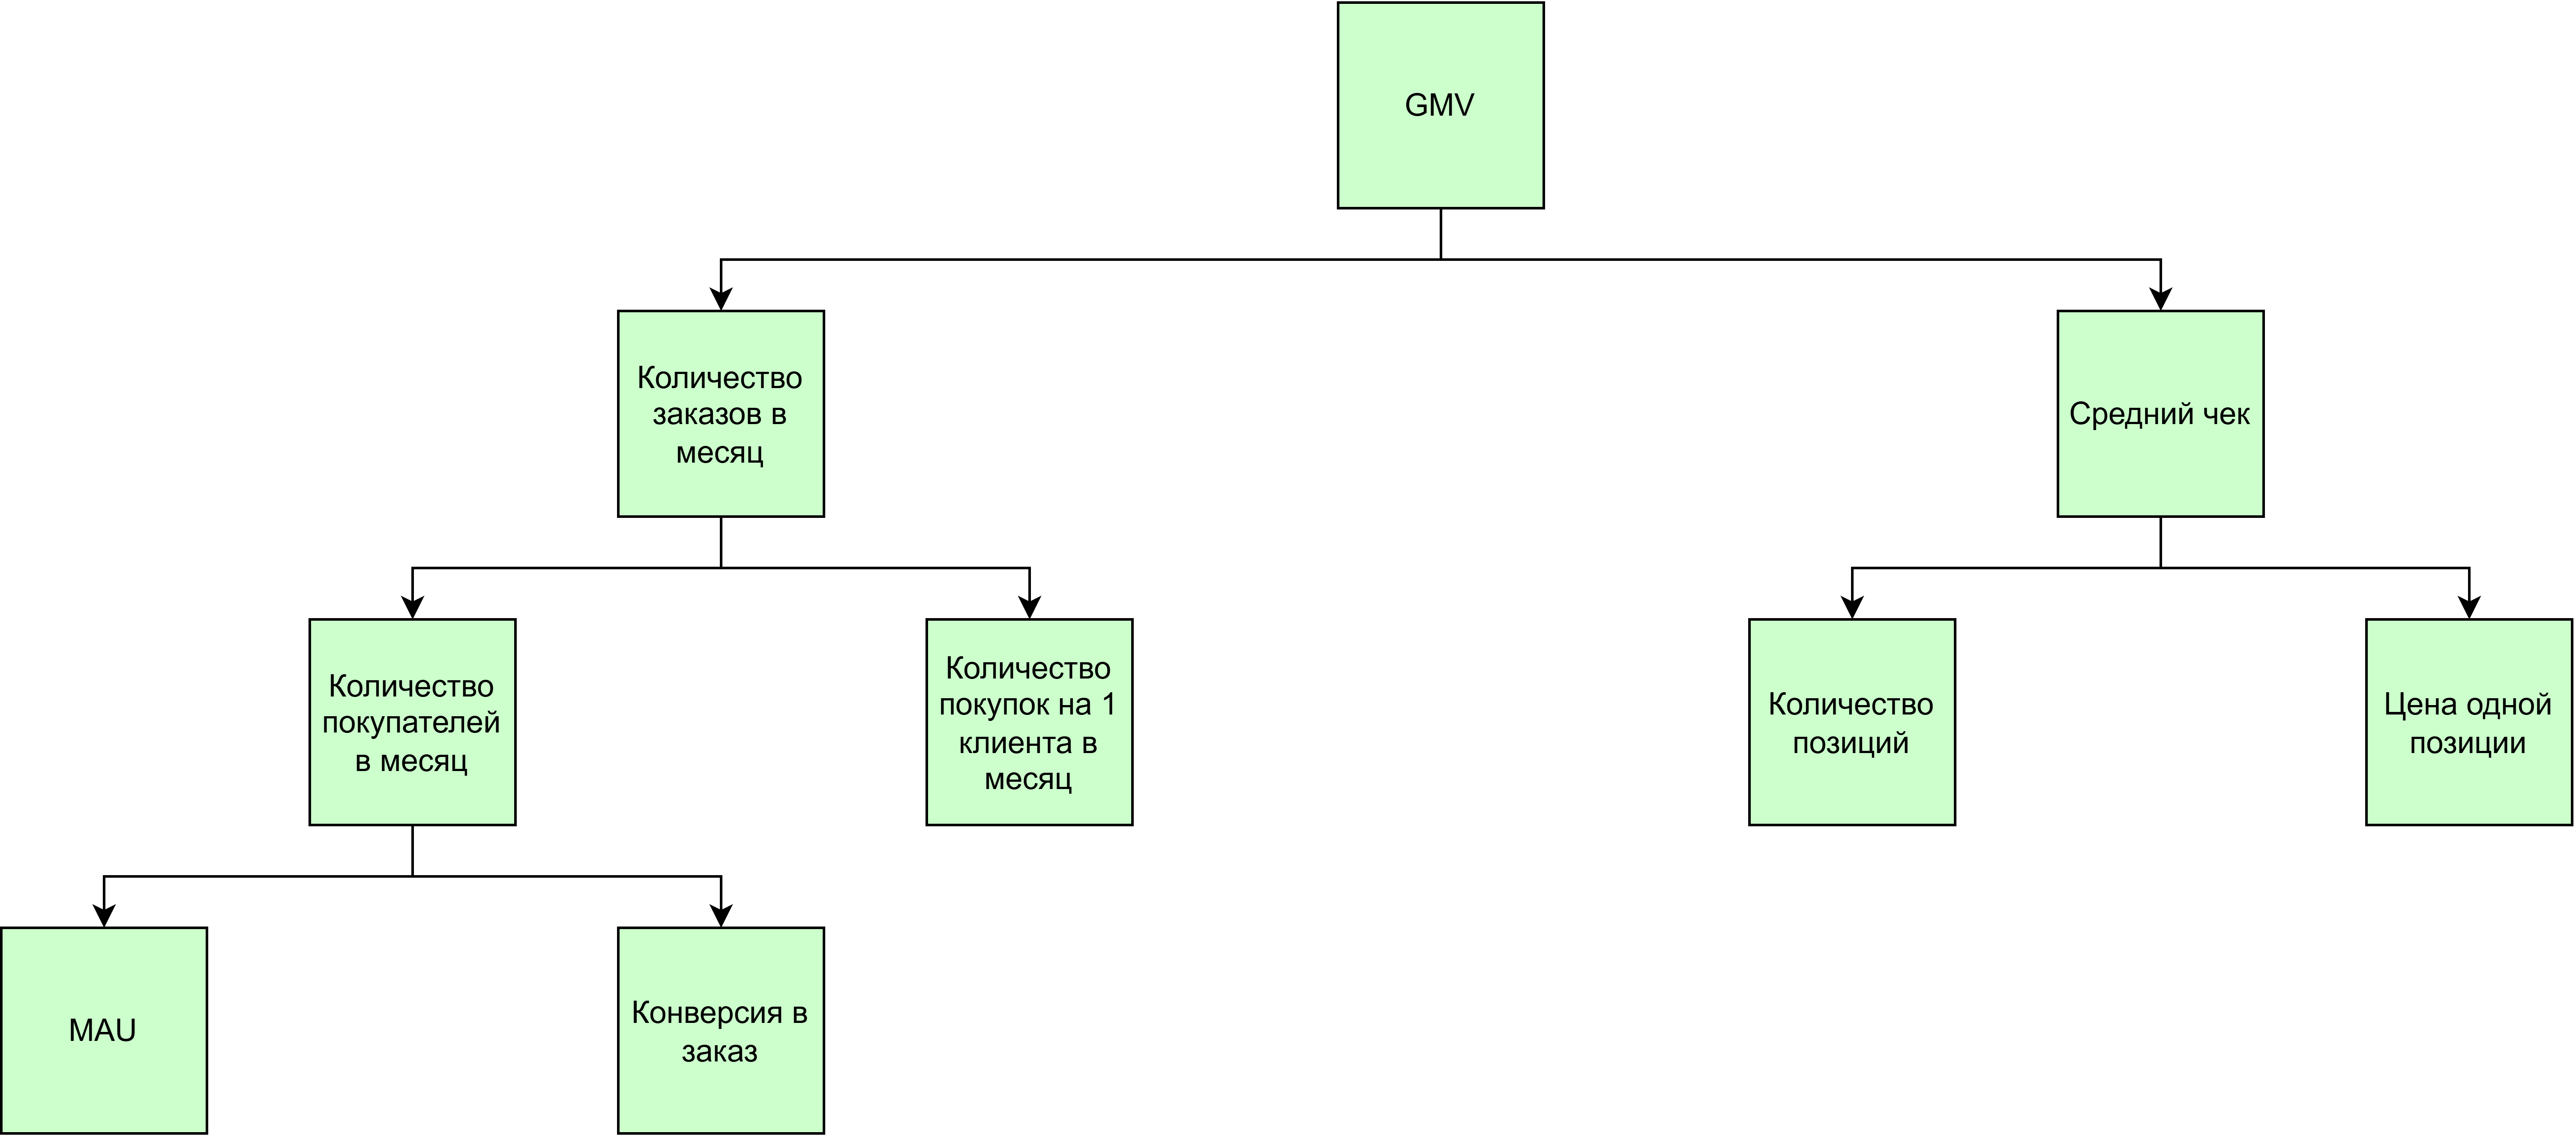

In [6]:
display(Image(filename=r"C:\Users\danye\T-academy\итоговый проект\дерево_nord_star.png"))

Дерево метрик: срезы

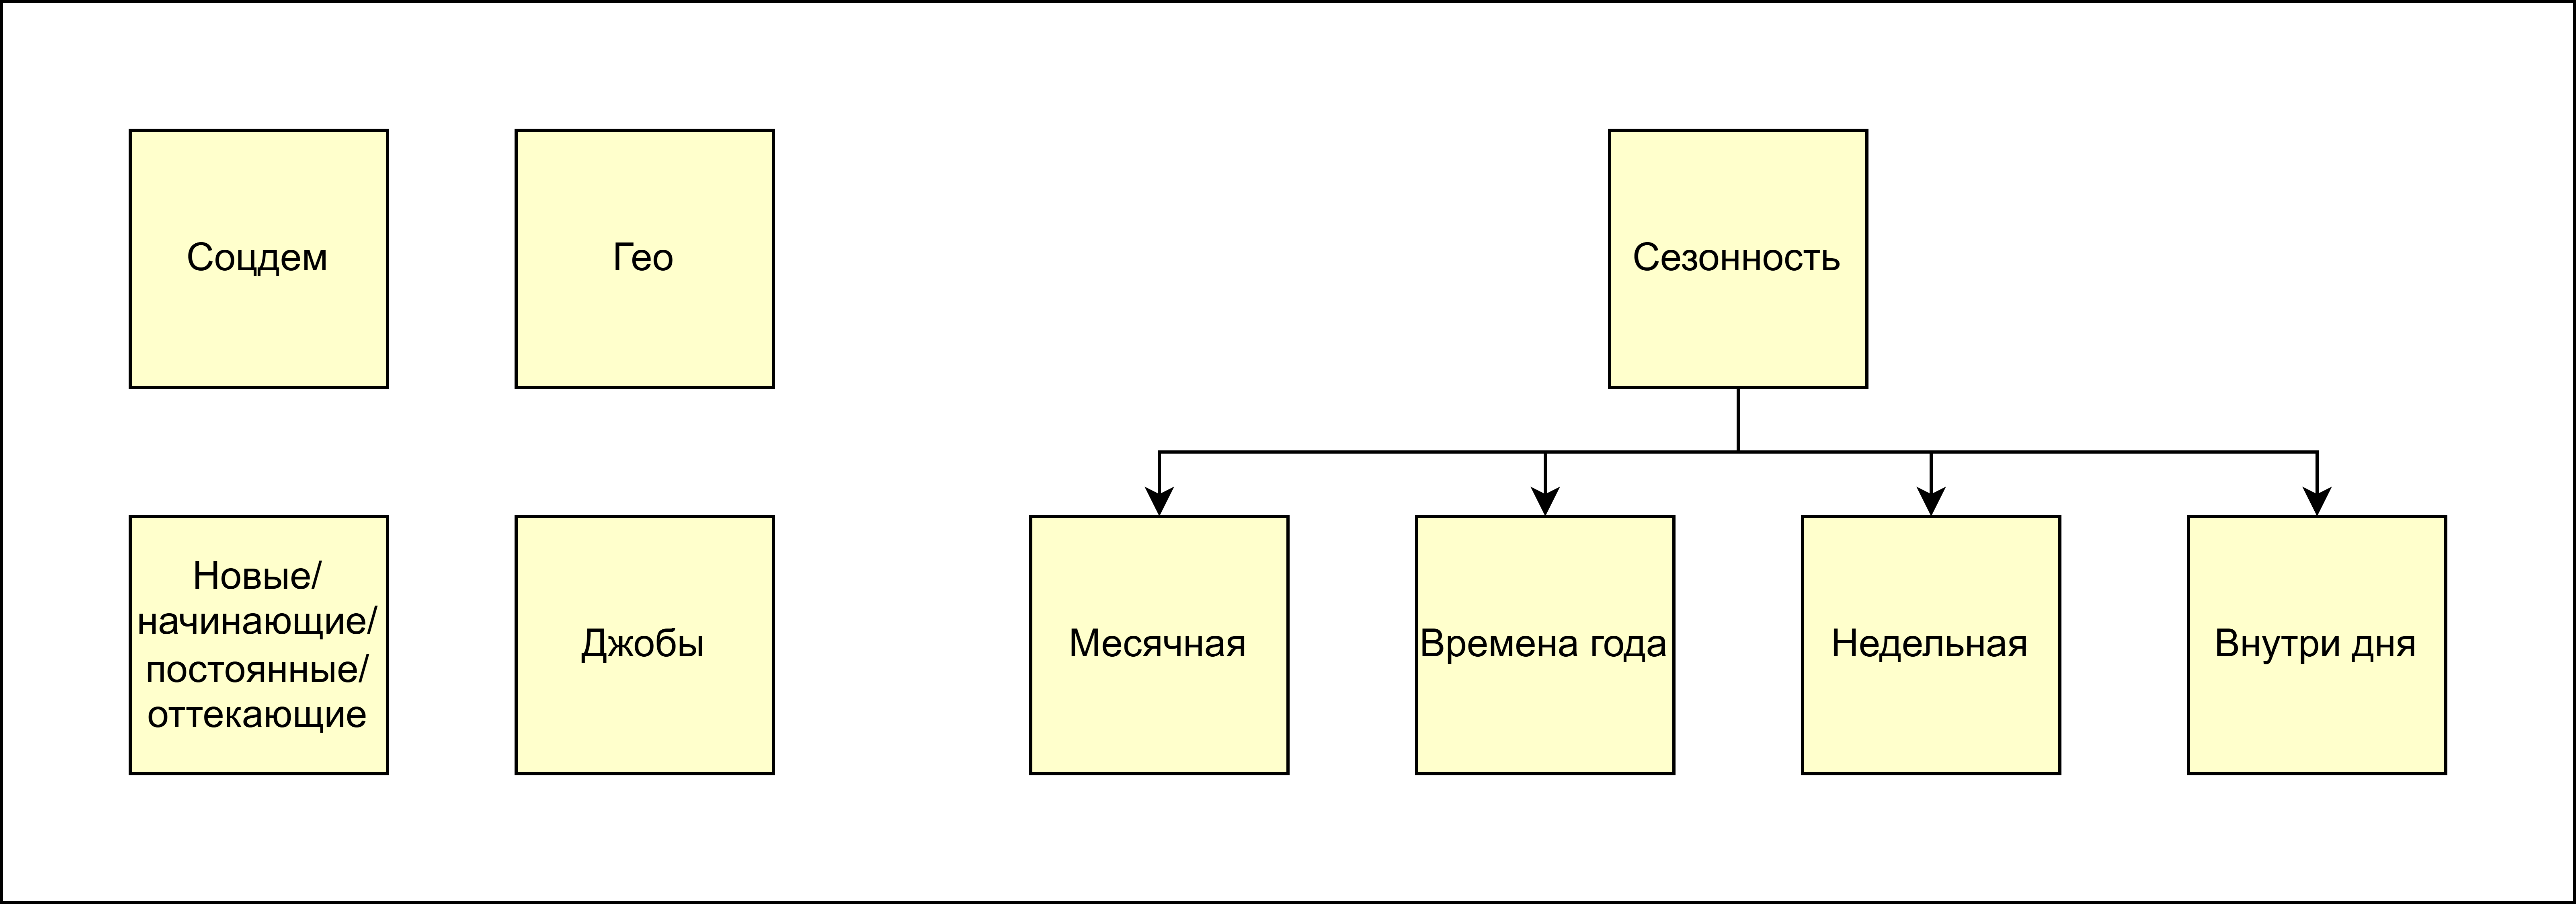

In [7]:
display(Image(filename=r"C:\Users\danye\T-academy\итоговый проект\дерево_срезов.png"))

---

Посмотрим динамику GMV

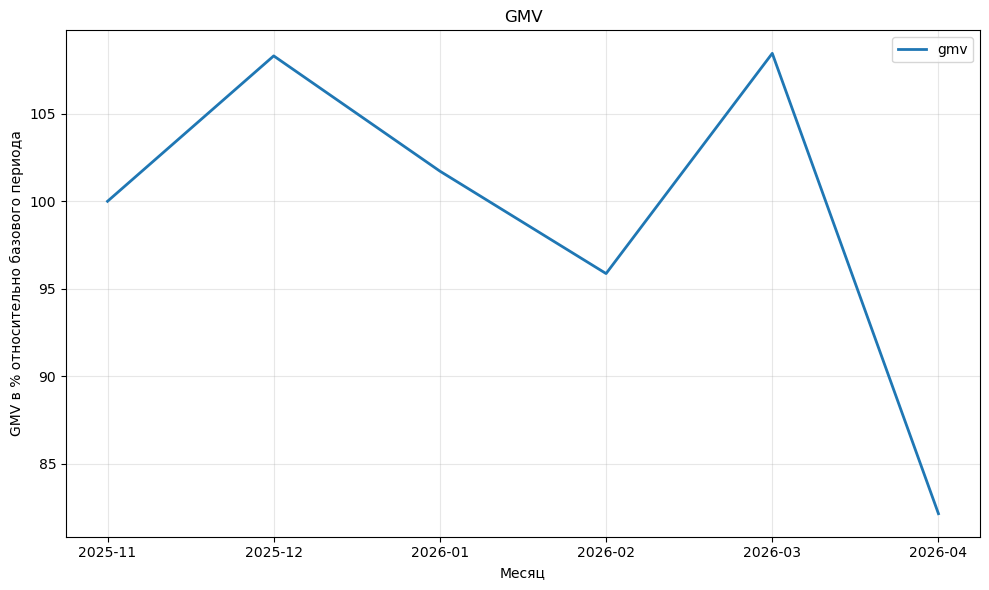

In [8]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_month'] = orders['order_date'].dt.strftime('%Y-%m')

gmv = orders.groupby('order_month')['gross_merchandise_value'].sum().reset_index(name='gmv')
#gmv.set_index('order_month', inplace=True)
#print(gmv)
gmv['gmv'] = gmv['gmv'] / gmv['gmv'][0] * 100

gmv.plot(x='order_month', y='gmv', figsize=(10, 6), linewidth=2)
plt.title('GMV')
plt.xlabel('Месяц')
plt.ylabel('GMV в % относительно базового периода')
plt.grid(True, alpha=0.3)
#plt.legend(title='Целевые действия')
plt.tight_layout()
plt.show()

-----

Для начала посмотрим, не повлиял ли проводимый аб-тест на GMV

Для этого проверим отсутствие статистически значимой разницы GMV между тестом и контролем

In [9]:
orders_test = orders[orders['experiment_group'] == 'test']
orders_control = orders[orders['experiment_group'] == 'control']
#orders_no_campaign = orders[orders['experiment_group'] == 'no_campaign']

gmv_test = orders_test.groupby('order_month')['gross_merchandise_value'].sum().reset_index(name='gmv_test')
gmv_control = orders_control.groupby('order_month')['gross_merchandise_value'].sum().reset_index(name='gmv_control')

t_stat, p_value = stats.ttest_ind(gmv_test['gmv_test'], gmv_control['gmv_control'], equal_var=False)

print(f'p_value is {p_value}')

p_value is 0.5506812041803041


p_value = 0.55 -> нулевая гипотеза об отсутствии статистической значимости не отвергается -> делаем вывод об отсутсвии влиянии проводимого 
теста на GMV

-------

Декомпозируем GMV. Посмотрим динамику метрик

In [10]:
funnel['session_date'] = pd.to_datetime(funnel['session_date'])
funnel['session_month'] = funnel['session_date'].dt.strftime('%Y-%m')

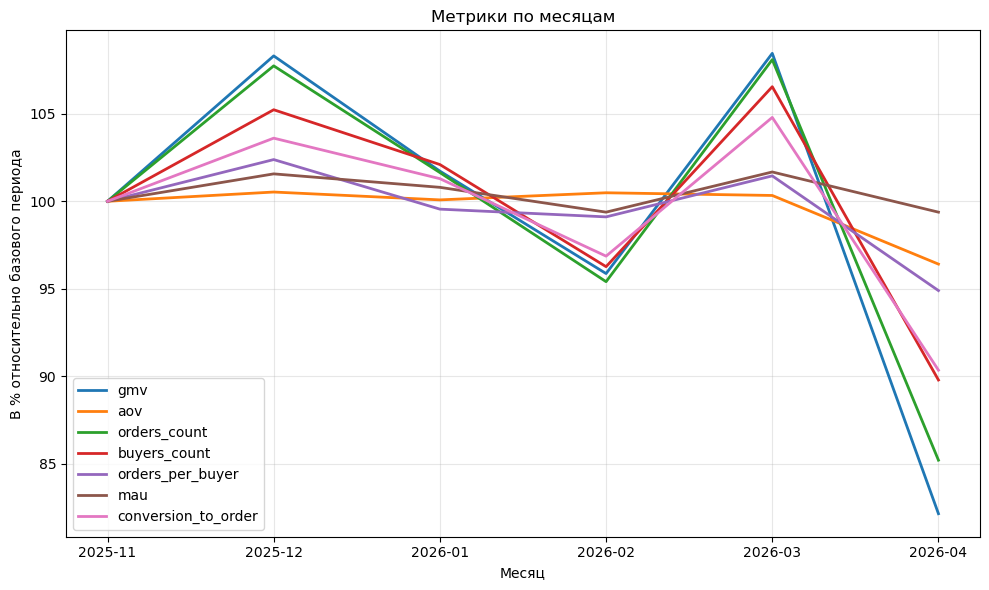

In [11]:
aov = orders.groupby('order_month')['gross_merchandise_value'].mean().reset_index(name='aov')
orders_count = orders.groupby('order_month')['order_id'].count().reset_index(name='orders_count')
buyers_count = orders.groupby('order_month')['client_id'].nunique().reset_index(name='buyers_count')
orders_per_buyer = pd.DataFrame({'order_month': orders_count['order_month'], 'orders_per_buyer': orders_count['orders_count'] / buyers_count['buyers_count']})
mau = funnel.groupby('session_month')['client_id'].nunique().reset_index(name='mau')
conversion_to_order = pd.DataFrame({'order_month': orders_count['order_month'], 'conversion_to_order': buyers_count['buyers_count'] / mau['mau']})

#aov.set_index('order_month', inplace=True)
#orders_count.set_index('order_month', inplace=True)
#buyers_count.set_index('order_month', inplace=True)
#orders_per_buyer.set_index('order_month', inplace=True)
mau.rename(columns={'session_month': 'order_month'}, inplace=True)
#mau.set_index('order_month', inplace=True)
#conversion_to_order.set_index('order_month', inplace=True)

aov['aov'] = aov['aov'] / aov['aov'][0] * 100
orders_count['orders_count'] = orders_count['orders_count'] / orders_count['orders_count'][0] * 100
buyers_count['buyers_count'] = buyers_count['buyers_count'] / buyers_count['buyers_count'][0] * 100
orders_per_buyer['orders_per_buyer'] = orders_per_buyer['orders_per_buyer'] / orders_per_buyer['orders_per_buyer'][0] * 100
mau['mau'] = mau['mau'] / mau['mau'][0] * 100
conversion_to_order['conversion_to_order'] = conversion_to_order['conversion_to_order'] / conversion_to_order['conversion_to_order'][0] * 100

metrics = gmv[['order_month', 'gmv']].copy()
for df in [aov, orders_count, buyers_count, orders_per_buyer, mau, conversion_to_order]:
    metrics = metrics.merge(df, on='order_month', how='outer')
#metrics = pd.concat([gmv, aov, orders_count, buyers_count, orders_per_buyer, mau, conversion_to_order])
#metrics.set_index('order')

#print(metrics.head(5))

metrics.plot(x='order_month', figsize=(10, 6), linewidth=2)
plt.title('Метрики по месяцам')
plt.xlabel('Месяц')
plt.ylabel('В % относительно базового периода')
plt.grid(True, alpha=0.3)
#plt.legend(title='Целевые действия')
plt.tight_layout()
plt.show()

Из графика имеем:
1. В основном падение GMV обусловлено падением количества заказов (хотя также наблюдается незначительное падение среднего чека)
2. Уменьшение количества заказов обусловлено в бошьшей степени падением количества покупателей в месяц и в меньшей - снижением количества заказов на одного покупателя
3. Снижение количества покупателей в месяц объясняется падением конверсии в заказ
4. Mau ведет себя относительно стабильно. Колебания стоит принять за шум

------------

Убедимся, что падение метрик не обусловлено аномальным количеством выходных дней в последнем месяце

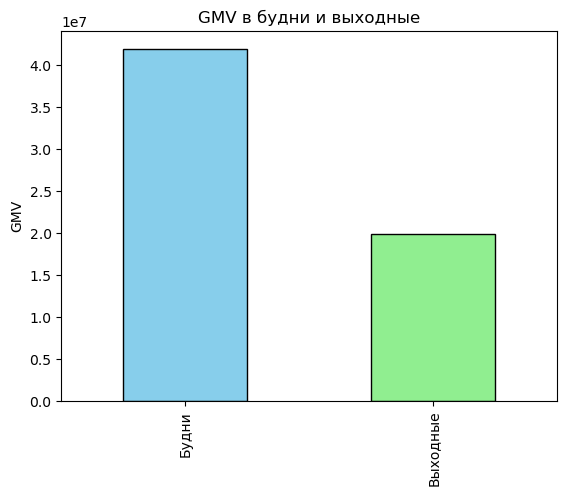

In [12]:
orders['weekday'] = orders['order_date'].dt.dayofweek
orders['is_weekend'] = orders['weekday'].isin([5, 6])

gmv_by_type = orders.groupby('is_weekend')['gross_merchandise_value'].sum()
gmv_by_type.index = ['Будни', 'Выходные']
gmv_by_type.plot(kind='bar', color=['skyblue', 'lightgreen'], edgecolor='black')
plt.title('GMV в будни и выходные')
plt.ylabel('GMV')
plt.show()

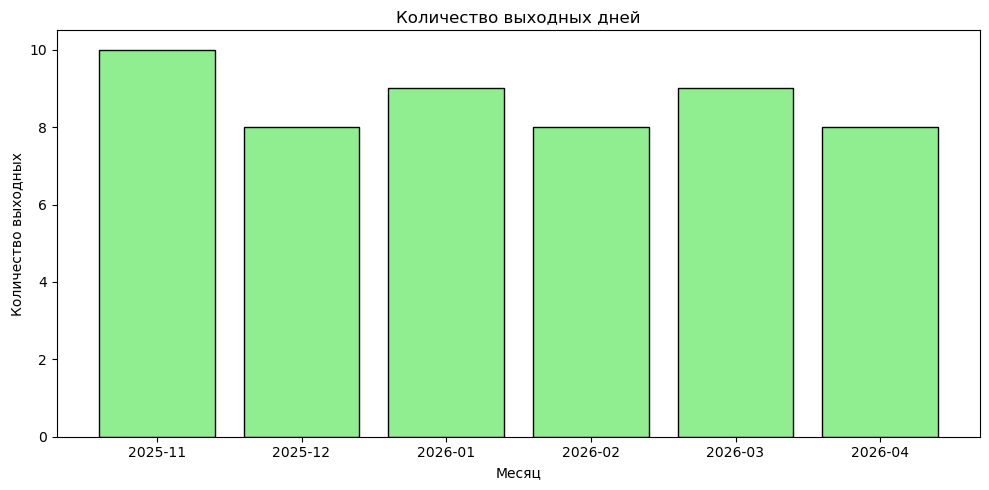

In [13]:
start_date = datetime(2025, 11, 1)
end_date = datetime(2026, 4, 30)

months = ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
weekend_counts = [10, 8, 9, 8, 9, 8]

plt.figure(figsize=(10, 5))
plt.bar(months, weekend_counts, color='lightgreen', edgecolor='black')
plt.title('Количество выходных дней')
plt.xlabel('Месяц')
plt.ylabel('Количество выходных')
#plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Как видно из графиков, в будни GMV выше, при этом в апреле всего 8 выходных дней. По этой причине фактор календаря отметаем как причину падения GMV

--------------------

Посмотрим средний чек по способам оплаты

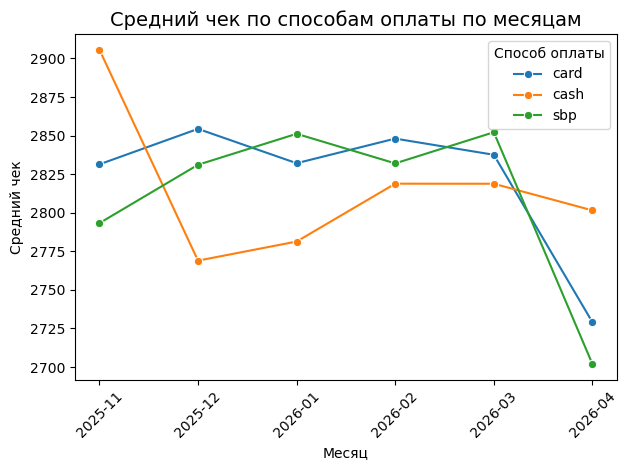

In [14]:
avg_check_by_payment_method = orders.groupby(['order_month', 'payment_method'])['gross_merchandise_value'].mean().reset_index()
avg_check_by_payment_method.columns = ['order_month', 'payment_method', 'avg_check']

sns.lineplot(data=avg_check_by_payment_method, x='order_month', y='avg_check', hue='payment_method', marker='o')

plt.title('Средний чек по способам оплаты по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средний чек')
plt.legend(title='Способ оплаты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

На графике видно резкое падение AOV в категориях безналичного расчета (card и sbp), что объясняет в целом падение среднего чека

Также это может являться косвенной причиной падения количества заказов на одного покупателя (проблемы с оплатой картой ухудшают удержание пользователя на второй заказ)

Проверим статистическую значимость

In [15]:
avg_check_by_payment_method = orders.groupby(['order_date', 'payment_method'])['gross_merchandise_value'].mean().reset_index()
avg_check_by_payment_method.columns = ['order_date', 'payment_method', 'avg_check']
avg_check_by_payment_method_april = avg_check_by_payment_method[(avg_check_by_payment_method['order_date'].dt.year == 2026) & (avg_check_by_payment_method['order_date'].dt.month == 4)]
avg_check_by_payment_method_not_april = avg_check_by_payment_method[(avg_check_by_payment_method['order_date'].dt.year != 2026) | (avg_check_by_payment_method['order_date'].dt.month != 4)]
avg_check_by_payment_method_april_cashless = avg_check_by_payment_method_april[(avg_check_by_payment_method_april['payment_method'] == 'card') | (avg_check_by_payment_method_april['payment_method'] == 'sbp')]
avg_check_by_payment_method_not_april_cashless = avg_check_by_payment_method_not_april[(avg_check_by_payment_method_not_april['payment_method'] == 'card') | (avg_check_by_payment_method_not_april['payment_method'] == 'sbp')]

t_stat, p_value = stats.ttest_ind(avg_check_by_payment_method_april_cashless['avg_check'], avg_check_by_payment_method_not_april['avg_check'], equal_var=False)

print(f'Падение среднего чека по безналичной оплате статистически значимо: {p_value < 0.05}')

Падение среднего чека по безналичной оплате статистически значимо: True


Как видно из т-теста: падение чека по безналичному расчету статистически значимо

Теперь посмотрим только за апрель

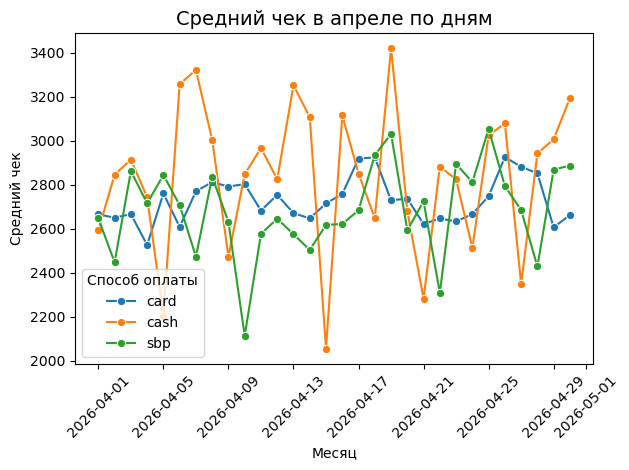

In [16]:
avg_check_by_payment_method = orders.groupby(['order_date', 'payment_method'])['gross_merchandise_value'].mean().reset_index()
avg_check_by_payment_method.columns = ['order_date', 'payment_method', 'avg_check']
avg_check_by_payment_method = avg_check_by_payment_method[(avg_check_by_payment_method['order_date'].dt.year == 2026) & (avg_check_by_payment_method['order_date'].dt.month == 4)]#.str.match(r'^2026-04-(0[1-9]|[12][0-9]|3[0])$', na=False)]

sns.lineplot(data=avg_check_by_payment_method, x='order_date', y='avg_check', hue='payment_method', marker='o')

plt.title('Средний чек в апреле по дням', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средний чек')
plt.legend(title='Способ оплаты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

График показывает отсутствие определенного временного промежутка проседания среднего чека по дням в апреле, что свидетельствует о том, что проблема имела системный характер на протяжение всего месяца

-------------------------------

Теперь посмотрим динамику сессий:

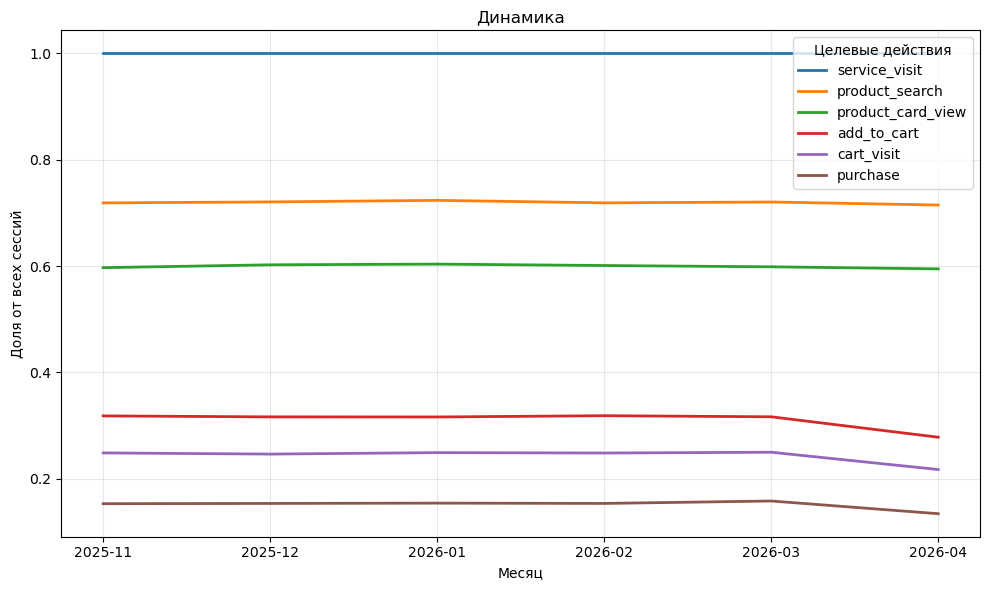

In [17]:
funnel['session_date'] = pd.to_datetime(funnel['session_date'])
funnel['session_month'] = funnel['session_date'].dt.strftime('%Y-%m')

month_session_results = funnel.groupby('session_month')[['service_visit', 'product_search', 'product_card_view', 'add_to_cart', 'cart_visit', 'purchase']].mean()

month_session_results.plot(figsize=(10, 6), linewidth=2)
plt.title('Динамика')
plt.xlabel('Месяц')
plt.ylabel('Доля от всех сессий')
plt.grid(True, alpha=0.3)
plt.legend(title='Целевые действия')
plt.tight_layout()
plt.show()

Как видно из графика, в последнем месяце наблюдается падение конверсии из активных пользователей в добавление товара в корзину

Это объясняет падение конверсии пользователей в заказ, и, как следствие, количества покупателей в месяц

Проверим статистическую значимость

In [18]:
month_session_results = funnel.groupby('session_date')[['service_visit', 'product_search', 'product_card_view', 'add_to_cart', 'cart_visit', 'purchase']].mean()
month_session_results_april = month_session_results[(month_session_results.index.year == 2026) & (month_session_results.index.month == 4)]
month_session_results_not_april = month_session_results[(month_session_results.index.year != 2026) | (month_session_results.index.month != 4)]

t_stat, p_value = stats.ttest_ind(month_session_results_april['add_to_cart'], month_session_results_not_april['add_to_cart'], equal_var=False)

print(f'Падение доли добавивших в корзину статистически значимо: {p_value < 0.05}')

Падение доли добавивших в корзину статистически значимо: True


Как видно из результатов теста, падение доли пользователей, добавивших товар в корзину, статистически значимо

Теперь посмотрим только за апрель

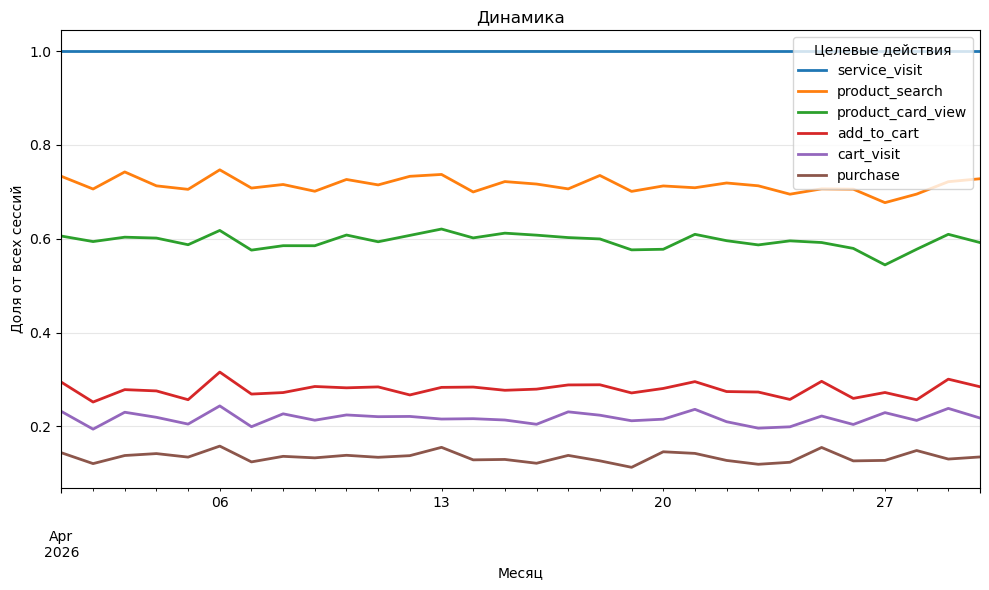

In [19]:
month_session_results_april = funnel.groupby('session_date')[['service_visit', 'product_search', 'product_card_view', 'add_to_cart', 'cart_visit', 'purchase']].mean()
month_session_results_april = month_session_results_april[(month_session_results_april.index.year == 2026) & (month_session_results_april.index.month == 4)]

month_session_results_april.plot(figsize=(10, 6), linewidth=2)
plt.title('Динамика')
plt.xlabel('Месяц')
plt.ylabel('Доля от всех сессий')
plt.grid(True, alpha=0.3)
plt.legend(title='Целевые действия')
plt.tight_layout()
plt.show()

Из графика видно, что в течение месяца воронка вела себя стабильно

--------

Посмотрим gmv в разрезе платформы:

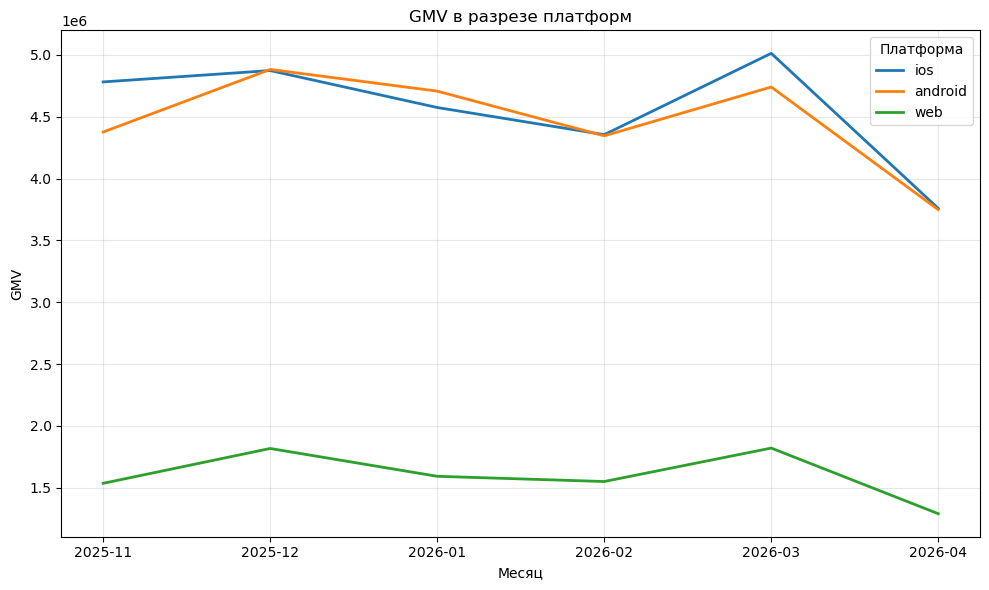

In [20]:
#orders_ios = orders[orders['platform'] == 'IOS']
orders['ios'] = orders['paid_amount'].where(orders['platform'] == 'ios', 0)
orders['android'] = orders['paid_amount'].where(orders['platform'] == 'android', 0)
orders['web'] = orders['paid_amount'].where(orders['platform'] == 'web', 0)

orders_gmv_by_platform = orders.groupby('order_month')[['ios', 'android', 'web']].sum()
orders_gmv_by_platform.plot(figsize=(10, 6), linewidth=2)
plt.title('GMV в разрезе платформ')
plt.xlabel('Месяц')
plt.ylabel('GMV')
plt.grid(True, alpha=0.3)
plt.legend(title='Платформа')
plt.tight_layout()
plt.show()

Из графика видно, что GMV упал сразу на всех платформах, что указывает на глобальность проблем, а не баги определенной ОС

------

Посмотрим коммуникации по месяцам

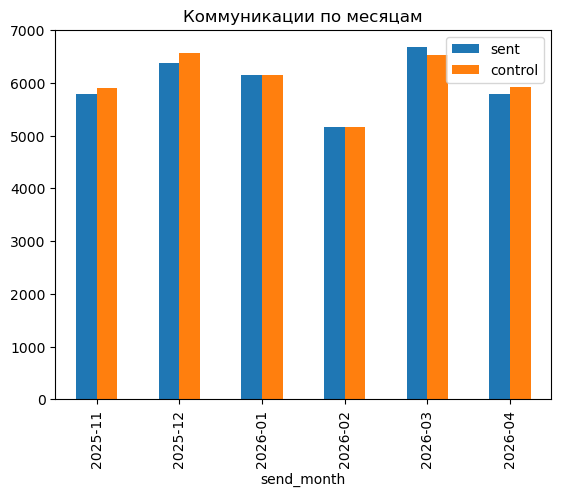

In [21]:
marketing_communications['send_date'] = pd.to_datetime(marketing_communications['send_date'])
marketing_communications['send_month'] = marketing_communications['send_date'].dt.to_period('M')
sent = marketing_communications[marketing_communications['send_status'] == 'sent'].groupby('send_month').size()
control = marketing_communications[marketing_communications['send_status'] == 'holdout_control'].groupby('send_month').size()
df_comm = pd.DataFrame({'sent': sent, 'control': control}).fillna(0)
df_comm.plot(kind='bar')
plt.title('Коммуникации по месяцам')
plt.show()

Аномалии за апрель отсутсвуют

Теперь посмотрим, как изменялась структура типа коммуникаций по месяцам

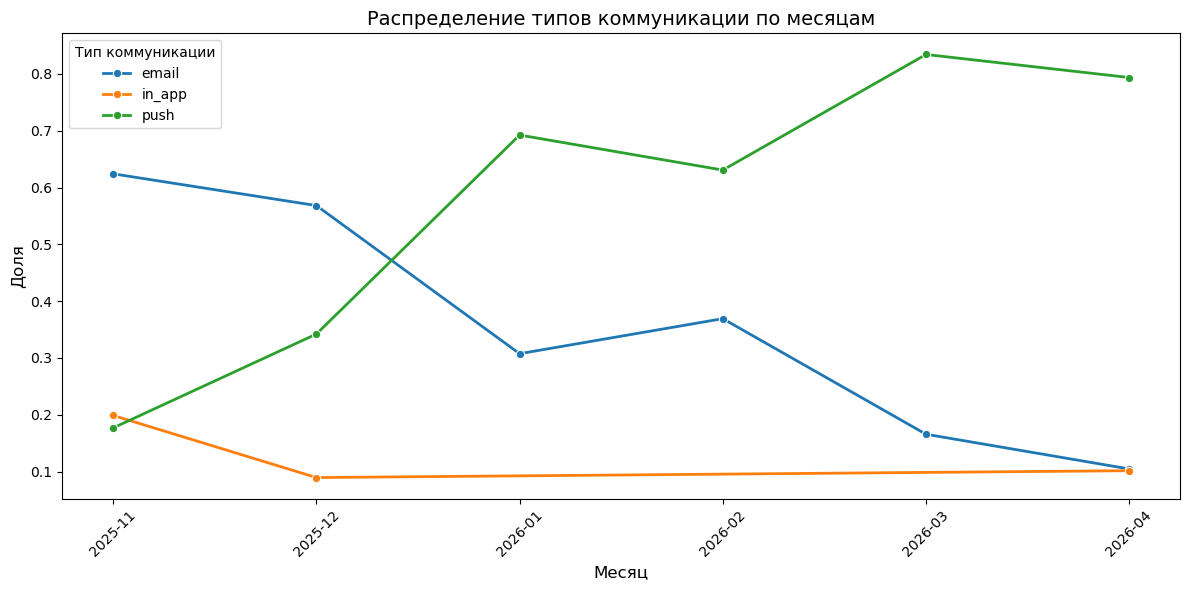

In [22]:
marketing_communications['month'] = marketing_communications['send_date'].dt.to_period('M').astype(str)
grouped = marketing_communications.groupby(['month', 'communication_type']).size().reset_index(name='count')
total_per_month = grouped.groupby('month')['count'].transform('sum')
grouped['share'] = grouped['count'] / total_per_month

plt.figure(figsize=(12, 6))
sns.lineplot(data=grouped, x='month', y='share', hue='communication_type', marker='o', linewidth=2)

plt.title('Распределение типов коммуникации по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Доля', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Тип коммуникации')
plt.tight_layout()
plt.show()

Как видно, есть тренд на увеличение доли пушей за счет уменьшения доли рассылки по почте. Вероятнее всего, это не является причиной падения GMV, так как данный эффект наблюдаем на протяжении всего периода, начиная с ноября 2025 года

Посмотрим на время коммуникаций по месяцам

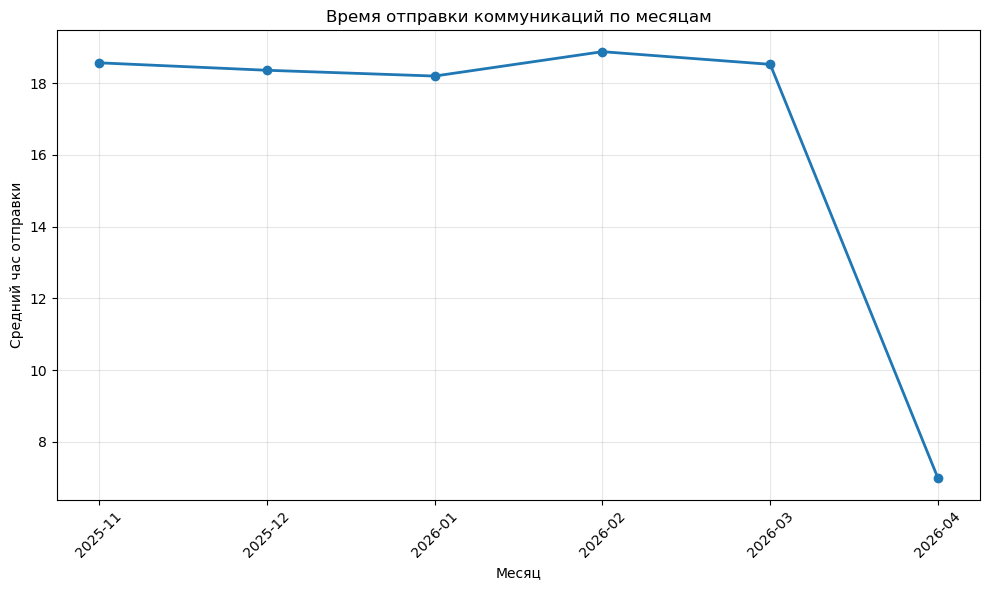

In [23]:
avg_hour_per_month = marketing_communications.groupby('month')['send_hour'].mean().reset_index()
avg_hour_per_month['month'] = avg_hour_per_month['month'].astype(str)

plt.figure(figsize=(10, 6))
plt.plot(avg_hour_per_month['month'], avg_hour_per_month['send_hour'], marker='o', linestyle='-', linewidth=2)
plt.title('Время отправки коммуникаций по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний час отправки')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Видим снижение среднего времени коммуникации с 18 до 7 часов

Для полной уверенности пострим график долей категории времени отправки коммуникации по месяцам

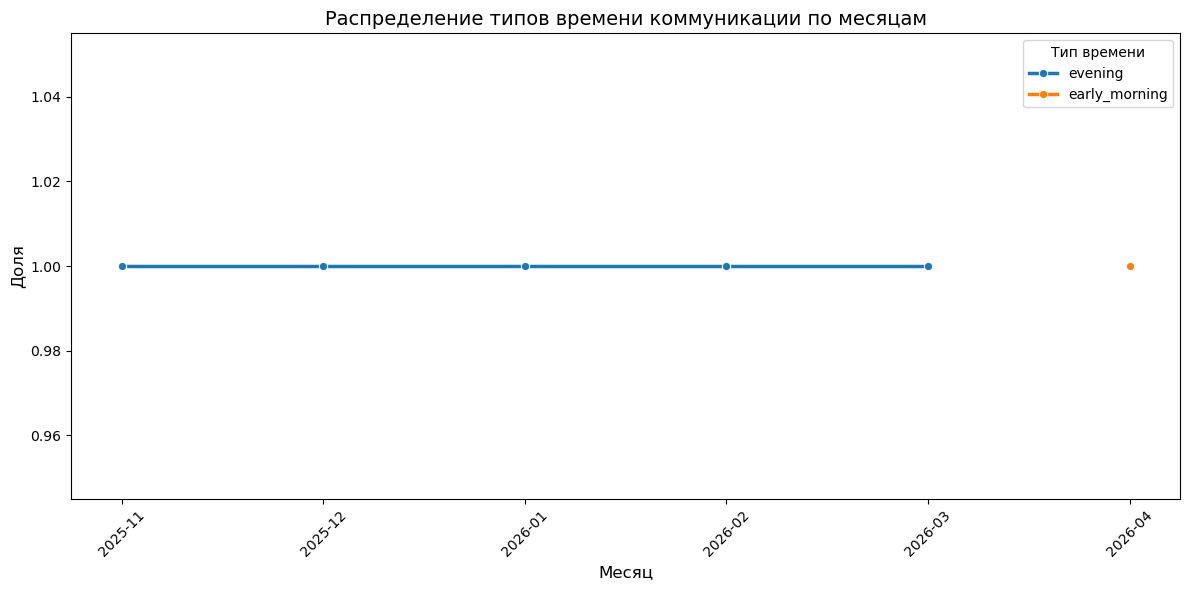

In [24]:
counts = marketing_communications.groupby(['month', 'timing_period']).size().reset_index(name='count')
total = counts.groupby('month')['count'].sum().reset_index(name='total')
counts = counts.merge(total, on='month')
counts['share'] = counts['count'] / counts['total']

plt.figure(figsize=(12, 6))
sns.lineplot(data=counts, x='month', y='share', hue='timing_period', marker='o', linewidth=2.5)

plt.title('Распределение типов времени коммуникации по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Доля', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Тип времени')
plt.tight_layout()
plt.show()

На графике видим, что раньше все коммуникации происходили по вечерам, а в апреле были перенесены на раннее утро

Именно это и послужило причиной падения конверсии в воронке

-----

Итоговая визуализация влияния проблем с бесконтактной оплатой и корзиной на GMV

In [26]:
gmv = orders.groupby('order_month')['gross_merchandise_value'].sum().reset_index(name='gmv')
aov = orders.groupby('order_month')['gross_merchandise_value'].mean().reset_index(name='aov')
orders_count = orders.groupby('order_month')['order_id'].count().reset_index(name='orders_count')

gmv_march = (float(gmv['gmv'][gmv['order_month'] == '2026-03']) * 0.000001).__round__(1)
gmv_april = (float(gmv['gmv'][gmv['order_month'] == '2026-04']) * 0.000001).__round__(1)

aov_diff = float(aov['aov'][aov['order_month'] == '2026-04']) - float(aov['aov'][aov['order_month'] == '2026-03'])
orders_count_diff = float(orders_count['orders_count'][orders_count['order_month'] == '2026-04']) - float(orders_count['orders_count'][orders_count['order_month'] == '2026-03'])

aov_march = float(aov['aov'][aov['order_month'] == '2026-03'])
orders_count_march = float(orders_count['orders_count'][orders_count['order_month'] == '2026-03'])
                                                        
diff = ((aov_march*orders_count_diff + aov_diff*orders_count_march + aov_diff*orders_count_diff) * 0.000001).__round__(1)

#aov_cashless_payment_diff = ((float(aov['aov'][aov['order_month'] == '2026-04']) - float(aov['aov'][aov['order_month'] == '2026-03'])) * float(orders_count['orders_count'][orders_count['order_month'] == '2026-03']) * 0.000001).__round__(1)
#orders_count_diff = ((float(orders_count['orders_count'][orders_count['order_month'] == '2026-04']) - float(orders_count['orders_count'][orders_count['order_month'] == '2026-03'])) * float(aov['aov'][aov['order_month'] == '2026-04']) * 0.000001).__round__(1)

categories = ['GMV март', 'падение конверсии корзины и AOV', 'GMV апрель']
deltas = [gmv_march, diff, gmv_april]
measures = ["absolute", "relative", "absolute"]

fig = go.Figure(
    go.Waterfall(
        name = "GMV", 
        orientation = "v", 
        measure = measures,
        x = categories,
        textposition = "outside",
        text = [gmv_march, diff, gmv_april],
        y = deltas,
        connector = {"line":{"color":"rgb(63, 63, 63)"}},
    ))
fig.update_layout(title = "GMV, млн. руб.", waterfallgap = 0.2)
fig.show()

C:\Users\danye\AppData\Local\Temp\ipykernel_35384\904039327.py:5: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

C:\Users\danye\AppData\Local\Temp\ipykernel_35384\904039327.py:6: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

C:\Users\danye\AppData\Local\Temp\ipykernel_35384\904039327.py:8: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

C:\Users\danye\AppData\Local\Temp\ipykernel_35384\904039327.py:9: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead

C:\Users\danye\AppData\Local\Temp\ipykernel_35384\904039327.py:11: FutureWarning:

Calling float on a single element Series is deprecated and will raise a T

-----

Выводы:

1. Проводимый тест не оказывает статистичекси значимого влияния на GMV

2. Падение GMV обусловлено двумя факторами: падением количества заказов и падением AOV

3. Падение AOV статистически значимо в безналичном расчете. Проблема однородна в разрезе ОС. Также в течение всего последнего месяца средний чек вёл себя стабильно (без явно выраженных периодов спада в рамках апреля)

4. Падение количества заказов обусловлено снижением конверсии активного пользователя в добавление товара в корзину. Также за весь последний месяц конверсия была стабильна, но имела статистически значимую разницу по сравнению с предыдущими периодами

5. Анализ коммуникаций выявил причину падения GMV: до последнего месяца все коммуникации происходили по вечерам, а в апреле были перенесены на раннее утро


Итоговая рекомендация: вернуть время коммуникаций с раннего утра на вечер